Import Libraries

In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

Load MNIST Dataset

In [2]:
(X_train, y_train), (X_test, y_test) = datasets.mnist.load_data()

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Training Data Shape: (60000, 28, 28)
Testing Data Shape: (10000, 28, 28)


Display Sample Images

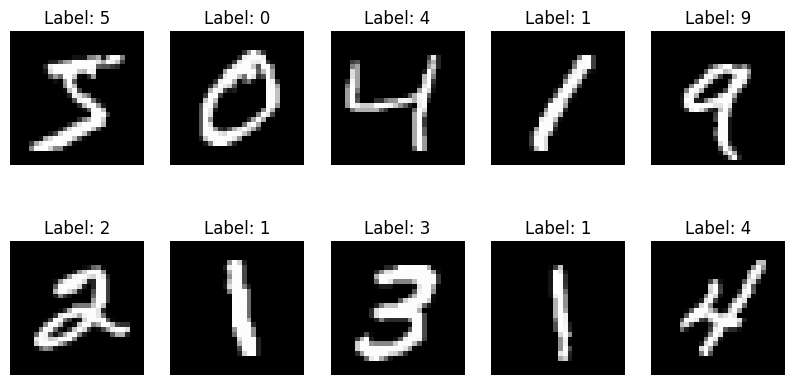

In [3]:
plt.figure(figsize=(10,5))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(f"Label: {y_train[i]}")
    plt.axis('off')

plt.show()

Normalize Data

In [4]:
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

print(X_train.shape)

(60000, 28, 28, 1)


Reshape Dataset

In [5]:
X_train = X_train.reshape((X_train.shape[0], 28, 28, 1))
X_test = X_test.reshape((X_test.shape[0], 28, 28, 1))

print(X_train.shape)

(60000, 28, 28, 1)


Build CNN Model

In [6]:
model = models.Sequential()

# First Convolution Layer
model.add(layers.Conv2D(32, (3,3), activation='relu',
                        input_shape=(28,28,1)))

model.add(layers.MaxPooling2D((2,2)))

# Second Convolution Layer
model.add(layers.Conv2D(64, (3,3), activation='relu'))

model.add(layers.MaxPooling2D((2,2)))

# Flatten Layer
model.add(layers.Flatten())

# Dense Layers
model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

# Compile Model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       102,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,930 (476.29 KB)

 Trainable params: 121,930 (476.29 KB)

 Non-trainable params: 0 (0.00 B)

Train Model

In [7]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_data=(X_test, y_test)
)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 33ms/step - accuracy: 0.9463 - loss: 0.2685 - val_accuracy: 0.9809 - val_loss: 0.0654
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 59s 32ms/step - accuracy: 0.9802 - loss: 0.0638 - val_accuracy: 0.9810 - val_loss: 0.0615
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 76s 40ms/step - accuracy: 0.9852 - loss: 0.0483 - val_accuracy: 0.9839 - val_loss: 0.0522
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 64s 31ms/step - accuracy: 0.9872 - loss: 0.0422 - val_accuracy: 0.9853 - val_loss: 0.0488
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 58s 31ms/step - accuracy: 0.9890 - loss: 0.0342 - val_accuracy: 0.9856 - val_loss: 0.0546


Evaluate Model

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.9856 - loss: 0.0546
Test Accuracy: 0.9855999946594238


Predict Digits

In [9]:
predictions = model.predict(X_test)

predicted_labels = np.argmax(predictions, axis=1)

print("Predicted Digit:", predicted_labels[0])
print("Actual Digit:", y_test[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step
Predicted Digit: 7
Actual Digit: 7


Display Prediction

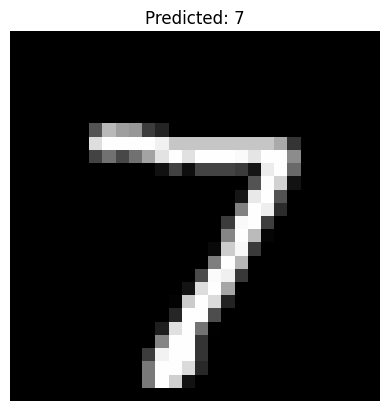

In [10]:
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f"Predicted: {predicted_labels[0]}")
plt.axis('off')
plt.show()

Classification Report

In [11]:
print(classification_report(y_test, predicted_labels))

              precision    recall  f1-score   support

           0       0.98      0.99      0.99       980
           1       0.99      0.99      0.99      1135
           2       0.99      0.98      0.98      1032
           3       0.98      0.99      0.99      1010
           4       0.99      0.99      0.99       982
           5       0.99      0.99      0.99       892
           6       0.99      0.99      0.99       958
           7       0.98      0.98      0.98      1028
           8       0.98      0.98      0.98       974
           9       0.99      0.98      0.98      1009

    accuracy                           0.99     10000
   macro avg       0.99      0.99      0.99     10000
weighted avg       0.99      0.99      0.99     10000



Confusion Matrix

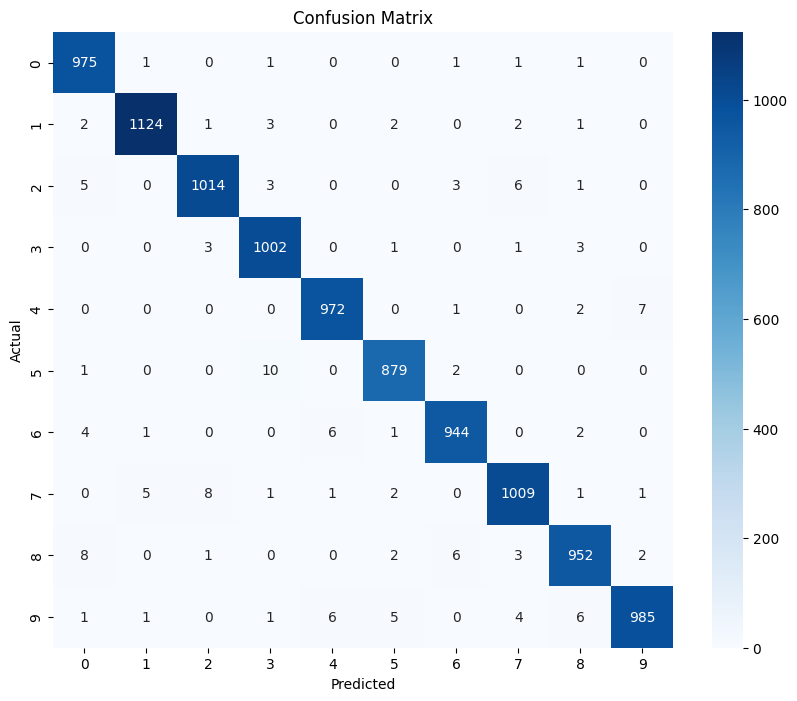

In [12]:
cm = confusion_matrix(y_test, predicted_labels)

plt.figure(figsize=(10,8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

Save Model

In [13]:
model.save("handwritten_digit_recognition_model.h5")

print("Model Saved Successfully!")

Model Saved Successfully!
